## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 4

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from scipy.stats import norm
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_4\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_4\initial_outputs.npy")

# INPUT file storing historical inputs 4D array (n, dim)
input_file = r"initial_data\function_4\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_4\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 42 points:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 4
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Because the system is dynamic and full of local optima,
- Conduct a grid research if the optimal output has not improved over several queries and exploration is insufficient.
- Alternate between UCB and EI if exploration seems insufficient.

In [4]:
grid_density = 50

acquisition_type = 'ucb'    # 'ucb' or 'ei'

In [5]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, bounds, n_candidates, beta):
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0)
    model.fit(X, y)
    # Generate candidate points
    candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Define a function to check whether the optimal output has been unimproved over several queries.
- Define a grid research function to find the point that maximizes the acquisition function.
- Increase `length_scale` of the kernel function to try to improve the fitness of model.

In [6]:
# Check if the optimal output has been unimproved
def check_unimproved(y, window = 3, tolerance = 1e-6):
    y_accumulate = np.maximum.accumulate(y)
    recent_best = y_accumulate[-window: ]
    return (np.max(recent_best) - np.min(recent_best)) < tolerance

# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # Generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    #kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
    #         + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-8, 0.1))
    # 20260630, change to Matern kernel
    kernel = Matern(nu = 1.5, length_scale = 1.0, length_scale_bounds = (1e-4, 100.0)) \
             + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 10))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0, normalize_y = True, n_restarts_optimizer = 5)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

Load historical data
Loaded 42 points. And the historical OUTPUT:
 [-22.10828779 -14.60139663 -11.69993246 -16.05376511 -10.06963343
 -15.48708254 -12.68168498 -16.02639977 -17.04923465 -12.74176599
 -27.31639636 -13.52764887 -16.6791152  -16.50715856 -17.81799934
 -26.56182083 -12.75832422 -19.44155762 -28.90327367 -13.70274694
 -29.4270914  -11.56574199 -26.85778644  -7.96677535  -6.70208925
 -32.62566022 -19.98949793  -4.02554228 -13.12278233 -23.1394284
 -22.68038164   0.63910178  -1.54224927  -3.82186544  -1.26378068
   0.57120658   0.54435233   0.62386567   0.62386567   0.57153856
  -0.0697988    0.49953577]
Current best output: 0.639102


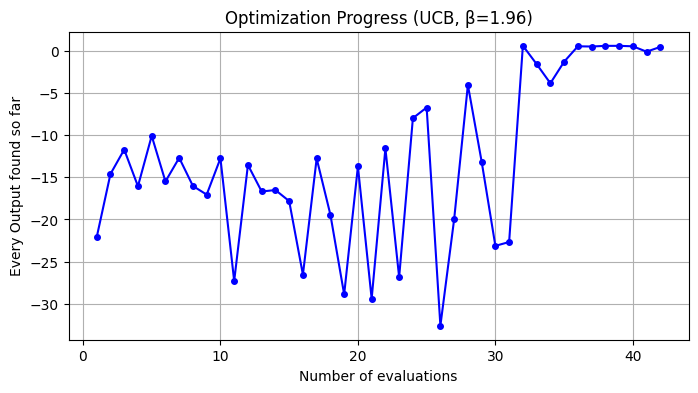

In [7]:
# 3. Load historical data and view current status
X, y = load_data()

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [8]:
# 4. Recommend the next point to submit
if check_unimproved(y):
    print("Detect output has been unimproved over several queries. Use grid research for exploration.")
    x_next, best_acquisition_value = grid_search_acquisition(X, y, bounds, grid_density, acquisition_type)
    print(f"Grid research selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    x_next, best_acquisition_value = suggest_next_point(X, y, bounds, n_candidates, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Detect output has been unimproved over several queries. Use grid research for exploration.


C:\Users\ligao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Use Upper Confidence Bound (UCB) acquisition function.
Predicted mean = 0.861242, std = 0.136217, UCB = 1.128229
Grid research selected point with acquisition value: 1.128229
The 13th recommended input point:
[0.387755 0.387755 0.387755 0.387755]
0.387755-0.387755-0.387755-0.387755


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)